# Sanity Check: Posterior P(C=1) vs PSE Shift Across Conflict Levels

**Motivation:** For the causal inference (lognorm) model, the PSE shift should be attenuated at large conflicts because P(C=1|m_a,m_v) drops — the observer should stop integrating. If PSE plots appear near-linear despite low posteriors, something may be off in the psychometric fit pipeline or the predicted effect is smaller than expected.

This notebook:
1. Computes expected P(C=1) per subject × conflict × noise level via Monte Carlo
2. Loads bootstrapped PSE values (data)
3. Correlates posterior with PSE shift per subject
4. Flags subjects with inconsistencies


## 1. Import Libraries and Configure Plot Settings


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as stats
import json
import os
import glob
from pathlib import Path
from scipy.stats import norm
from collections import defaultdict

import loadData
import monteCarloClass
import loadResults

# ── Publication-ready plot settings (matching existing notebooks) ──────────────
FONT_SIZE_LABEL  = 18
FONT_SIZE_TITLE  = 20
FONT_SIZE_LEGEND = 18

plt.rcParams.update({
    'font.size':          FONT_SIZE_LABEL,
    'axes.labelsize':     FONT_SIZE_LABEL,
    'axes.titlesize':     FONT_SIZE_TITLE,
    'xtick.labelsize':    FONT_SIZE_LABEL,
    'ytick.labelsize':    FONT_SIZE_LABEL,
    'legend.fontsize':    FONT_SIZE_LEGEND,
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth':     1.5,
    'lines.linewidth':    2.0,
    'lines.markersize':   8,
    'xtick.major.width':  1.5,
    'ytick.major.width':  1.5,
    'xtick.major.size':   6,
    'ytick.major.size':   6,
    'legend.frameon':     True,
    'legend.framealpha':  0.8,
    'legend.edgecolor':   'black',
    'figure.dpi':         100,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'axes.grid':          False,
})
print("✓ Plot configuration loaded")


✓ Plot configuration loaded


## 2. Load Model Fit Results and Set Up Participant/Model Lists


In [2]:
def load_all_model_results():
    """Load LapseFix (sharedLambda=True) model fits; skip deprecated models."""
    results = []
    json_files = glob.glob("model_fits/**/*.json", recursive=True)
    excluded_models = [
        "gaussian_sharedPrior", "fusionOnly_sharedPrior",
        "probabilityMatching_sharedPrior", "switching_sharedPrior"
    ]
    for file_path in json_files:
        try:
            with open(file_path, 'r') as f:
                result = json.load(f)
            filename = os.path.basename(file_path)
            parts = filename.replace('.json', '').split('_')
            if 'participantID' not in result:
                result['participantID'] = parts[0]
            result['modelType'] = parts[1] + "_" + parts[3]
            # Keep only LapseFix (sharedLambda=True)
            if parts[2] == "LapseFree":
                continue
            if any(m in result['modelType'] for m in excluded_models):
                continue
            results.append(result)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return results

all_results = load_all_model_results()
df_results  = pd.DataFrame(all_results)
participantIds = sorted(df_results['participantID'].unique())
modelTypes     = sorted(df_results['modelType'].unique())

print(f"Loaded {len(all_results)} model fit results")
print(f"Participants ({len(participantIds)}): {participantIds}")
print(f"Models ({len(modelTypes)}): {modelTypes}")


Loaded 71 model fit results
Participants (12): ['all', 'as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']
Models (6): ['fusionOnlyLogNorm_sharedPrior', 'logLinearMismatch_sharedPrior', 'lognorm_sharedPrior', 'probabilityMatchingLogNorm_sharedPrior', 'selection_sharedPrior', 'switchingFree_sharedPrior']


## 3. Define Causal Inference Helper Functions (Log-Space Convention)

For the **lognorm** model, measurements are in log-space:
- `m_a ~ N(log(S_a), σ_a)`, `m_v ~ N(log(S_v), σ_v)`
- Likelihoods are evaluated with `t_min = log(data_t_min)`, `t_max = log(data_t_max)`

So the posterior P(C=1) is computed from log-space measurements.


In [3]:
def p_single(m, sigma, t_min, t_max):
    """Marginal likelihood p(m | C=2): N(m; y, sigma²) integrated over uniform prior on [t_min, t_max]."""
    hi = norm.cdf((t_max - m) / sigma)
    lo = norm.cdf((t_min - m) / sigma)
    return (hi - lo) / (t_max - t_min)


def L_C1(m_a, m_v, sigma_a, sigma_v, t_min, t_max):
    """Likelihood of common cause: p(m_a, m_v | C=1)."""
    sigma_c = np.sqrt(sigma_a**2 * sigma_v**2 / (sigma_a**2 + sigma_v**2))
    mu_c = (m_a / sigma_a**2 + m_v / sigma_v**2) / (1 / sigma_a**2 + 1 / sigma_v**2)
    hi = norm.cdf((t_max - mu_c) / sigma_c)
    lo = norm.cdf((t_min - mu_c) / sigma_c)
    expo = np.exp(-(m_a - m_v)**2 / (2 * (sigma_a**2 + sigma_v**2)))
    prior = 1.0 / (t_max - t_min)
    return prior * sigma_c / np.sqrt(sigma_a**2 * sigma_v**2) * (hi - lo) * expo


def L_C2(m_a, m_v, sigma_a, sigma_v, t_min, t_max):
    """Likelihood of separate causes: p(m_a, m_v | C=2)."""
    return p_single(m_a, sigma_a, t_min, t_max) * p_single(m_v, sigma_v, t_min, t_max)


def posterior_C1(m_a, m_v, sigma_a, sigma_v, p_c, t_min, t_max):
    """Posterior P(C=1 | m_a, m_v) using Bayes' rule."""
    l1 = L_C1(m_a, m_v, sigma_a, sigma_v, t_min, t_max)
    l2 = L_C2(m_a, m_v, sigma_a, sigma_v, t_min, t_max)
    lratio = l1 / (l2 + 1e-20)
    return lratio * p_c / (lratio * p_c + (1 - p_c))


def compute_expected_posterior(sigma_a, sigma_v, p_c, log_t_min, log_t_max,
                                S_a=0.5, conflict=0.0, nSimul=5000, rng=None):
    """
    Monte Carlo estimate of E[P(C=1)] at a given conflict level.
    Uses log-space measurements matching the lognorm model convention.
    
    Returns nan if S_v <= 0.
    """
    S_v = S_a + conflict
    if S_v <= 0:
        return np.nan
    rng = rng or np.random.default_rng(42)
    m_a = rng.normal(np.log(S_a), sigma_a, nSimul)
    m_v = rng.normal(np.log(S_v), sigma_v, nSimul)
    post = posterior_C1(m_a, m_v, sigma_a, sigma_v, p_c, log_t_min, log_t_max)
    return float(np.mean(post))


print("✓ Causal inference helper functions defined")


✓ Causal inference helper functions defined


## 4. Compute Per-Subject Posterior P(C=1) Across Conflict Levels

For each participant: load lognorm fit params → extract σ_a (low & high noise), σ_v, p_c → Monte Carlo sample measurements → compute mean posterior per condition.


In [4]:
NSIML = 5000   # Monte Carlo samples per condition
rng = np.random.default_rng(0)

# Participants to analyse (skip first if it is a pooled/special entry)
pids_to_analyse = participantIds[1:]

posterior_rows = []

for pid in pids_to_analyse:
    # ── Load lognorm fit result ──────────────────────────────────────
    row = df_results[(df_results['participantID'] == pid) &
                     (df_results['modelType'] == 'lognorm_sharedPrior')]
    if row.empty:
        print(f"No lognorm_sharedPrior fit for {pid}, skipping.")
        continue
    fitted_params = row.iloc[0]['fittedParams']

    # ── Load data to get condition structure and data bounds ─────────
    try:
        data, dataName = loadData.loadData(pid + "_all.csv", verbose=False)
    except Exception as e:
        print(f"Cannot load data for {pid}: {e}")
        continue

    mc = monteCarloClass.OmerMonteCarlo(data)
    mc.modelName  = "lognorm"
    mc.sharedLambda = True
    mc.freeP_c    = False
    mc.dataName   = dataName

    # Log-space bounds (lognorm model uses log-space measurements)
    log_t_min = np.log(mc.data_t_min)
    log_t_max = np.log(mc.data_t_max)

    # Fitted model params layout (sharedLambda=True, freeP_c=False):
    # [λ, σa_low, σv, p_c, σa_high]  → indices 1, 2, 3, 4
    sigma_a_low  = fitted_params[1]
    sigma_v      = fitted_params[2]
    p_c          = fitted_params[3]
    sigma_a_high = fitted_params[4]

    sigma_a_map = {
        sorted(mc.uniqueSensory)[0]: sigma_a_low,
        sorted(mc.uniqueSensory)[1]: sigma_a_high,
    }

    for noise_level in sorted(mc.uniqueSensory):
        sigma_a = sigma_a_map[noise_level]
        for conflict in sorted(mc.uniqueConflict):
            mean_post = compute_expected_posterior(
                sigma_a=sigma_a, sigma_v=sigma_v, p_c=p_c,
                log_t_min=log_t_min, log_t_max=log_t_max,
                S_a=0.5, conflict=conflict,
                nSimul=NSIML, rng=rng
            )
            posterior_rows.append({
                'participantID': pid,
                'audioNoise':    noise_level,
                'conflict_s':    conflict,
                'conflict_ms':   int(round(conflict * 1000)),
                'mean_posterior': mean_post,
                'sigma_a':       sigma_a,
                'sigma_v':       sigma_v,
                'p_c':           p_c,
            })

df_posterior = pd.DataFrame(posterior_rows)
print(f"Computed posteriors: {len(df_posterior)} rows")
print(df_posterior.groupby(['audioNoise', 'conflict_ms'])['mean_posterior'].mean().round(3).to_string())


Computed posteriors: 154 rows
audioNoise  conflict_ms
0.1         -250           0.752
            -170           0.819
            -80            0.856
             0             0.867
             80            0.868
             170           0.861
             250           0.852
1.2         -250           0.818
            -170           0.836
            -80            0.845
             0             0.849
             80            0.850
             170           0.850
             250           0.848


## 5. Load Bootstrapped PSE Values Per Subject and Conflict Level


In [5]:
pse_rows = []

for pid in pids_to_analyse:
    boot_path = os.path.join(
        "bootstrapped_params", pid.split('_')[0],
        f"{pid}_dataFit_bootstrapped_params.json"
    )
    if not os.path.exists(boot_path):
        print(f"Missing bootstrap file for {pid}")
        continue
    try:
        with open(boot_path, 'r') as f:
            boots = json.loads(f.read().strip())
        if not boots:
            continue
    except Exception as e:
        print(f"Error reading {boot_path}: {e}")
        continue

    try:
        data, dataName = loadData.loadData(pid + "_all.csv", verbose=False)
    except Exception as e:
        print(f"Error loading data for {pid}: {e}")
        continue

    mc = monteCarloClass.OmerMonteCarlo(data)
    mc.freeP_c    = False
    mc.sharedLambda = True
    mc.dataName   = dataName

    for noise_level in sorted(mc.uniqueSensory):
        for conflict in sorted(mc.uniqueConflict):
            try:
                mus = [mc.getParams(b, conflict, noise_level)[1] for b in boots]
            except Exception as e:
                print(f"  getParams error for {pid} c={conflict:.3f} n={noise_level}: {e}")
                continue
            mus_ms = np.array(mus) * 1000   # convert seconds → ms
            pse_rows.append({
                'participantID': pid,
                'audioNoise':    noise_level,
                'conflict_s':    conflict,
                'conflict_ms':   int(round(conflict * 1000)),
                'mean_pse_ms':   float(np.mean(mus_ms)),
                'std_pse_ms':    float(np.std(mus_ms)),
                'sem_pse_ms':    float(np.std(mus_ms) / np.sqrt(len(mus_ms))),
            })

df_pse = pd.DataFrame(pse_rows)
print(f"PSE rows loaded: {len(df_pse)}")
print(df_pse.groupby(['audioNoise', 'conflict_ms'])['mean_pse_ms'].mean().round(2).to_string())


PSE rows loaded: 154
audioNoise  conflict_ms
0.1         -250           -27.70
            -170           -16.54
            -80             18.19
             0              13.12
             80             23.04
             170            41.58
             250            48.96
1.2         -250          -140.21
            -170           -90.26
            -80             13.96
             0              41.77
             80            103.49
             170           111.54
             250           114.83


## 6. Correlate Posterior P(C=1) with PSE Shift Per Subject

Merge the two DataFrames and compute Pearson r and Spearman ρ per participant × noise level.

**Sanity-check logic:** Under causal inference, higher P(C=1) → stronger visual capture → larger |PSE shift|.  
A near-zero or negative correlation would indicate the predicted mechanism is not reflected in the PSE data.


In [6]:
# ── Merge posterior and PSE DataFrames ───────────────────────────────────────
df_merged = pd.merge(
    df_posterior, df_pse,
    on=['participantID', 'audioNoise', 'conflict_ms', 'conflict_s'],
    how='inner'
)
print(f"Merged rows: {len(df_merged)}  |  "
      f"Participants: {df_merged['participantID'].nunique()}  |  "
      f"Conditions: {df_merged.groupby(['audioNoise','conflict_ms']).ngroups}")

# ── Correlation per participant × noise level ─────────────────────────────────
corr_rows = []
for pid in sorted(df_merged['participantID'].unique()):
    for noise_level in sorted(df_merged['audioNoise'].unique()):
        sub = df_merged[
            (df_merged['participantID'] == pid) &
            (df_merged['audioNoise'] == noise_level)
        ].dropna(subset=['mean_posterior', 'mean_pse_ms'])

        if len(sub) < 3:
            continue

        x = sub['mean_posterior'].values
        y = sub['mean_pse_ms'].values

        # We use |PSE| because larger conflict → lower posterior AND larger |PSE| in both directions
        y_abs = np.abs(y)

        pr, pp   = stats.pearsonr(x, y_abs)
        sr, sp   = stats.spearmanr(x, y_abs)

        # Also compute raw (signed) correlation
        pr_raw, pp_raw = stats.pearsonr(x, y)

        corr_rows.append({
            'participantID':    pid,
            'audioNoise':       noise_level,
            'noise_label':      'Low noise' if noise_level == sorted(df_merged['audioNoise'].unique())[0] else 'High noise',
            'pearson_r_abs':    round(pr, 3),
            'pearson_p_abs':    round(pp, 4),
            'pearson_r_signed': round(pr_raw, 3),
            'spearman_rho':     round(sr, 3),
            'spearman_p':       round(sp, 4),
            'n_conditions':     len(sub),
        })

df_corr = pd.DataFrame(corr_rows)
print("\n── Pearson r(|posterior|, |PSE|) per participant × noise ──")
print(df_corr[['participantID', 'noise_label', 'pearson_r_abs', 'pearson_p_abs',
               'pearson_r_signed', 'spearman_rho', 'spearman_p']].to_string(index=False))


Merged rows: 154  |  Participants: 11  |  Conditions: 14

── Pearson r(|posterior|, |PSE|) per participant × noise ──
participantID noise_label  pearson_r_abs  pearson_p_abs  pearson_r_signed  spearman_rho  spearman_p
           as   Low noise          0.375         0.4078             0.632         0.571      0.1802
           as  High noise         -0.689         0.0869             0.865        -0.464      0.2939
           dt   Low noise         -0.510         0.2427             0.572        -0.571      0.1802
           dt  High noise          0.039         0.9338             0.530        -0.393      0.3833
           hh   Low noise         -0.548         0.2025             0.672        -0.429      0.3374
           hh  High noise         -0.945         0.0013             0.239        -0.964      0.0005
           ip   Low noise          0.073         0.8768             0.073        -0.036      0.9394
           ip  High noise          0.410         0.3614             0.636         

## 7. Scatter Plot: Posterior P(C=1) vs PSE Shift — Per Subject, Per Noise Level

Each point = one conflict level condition. Color = |conflict| magnitude (darker = larger conflict).  
If the model is working correctly: **higher posterior → larger PSE shift**.  
Near-flat or reversed scatter patterns indicate a problem.


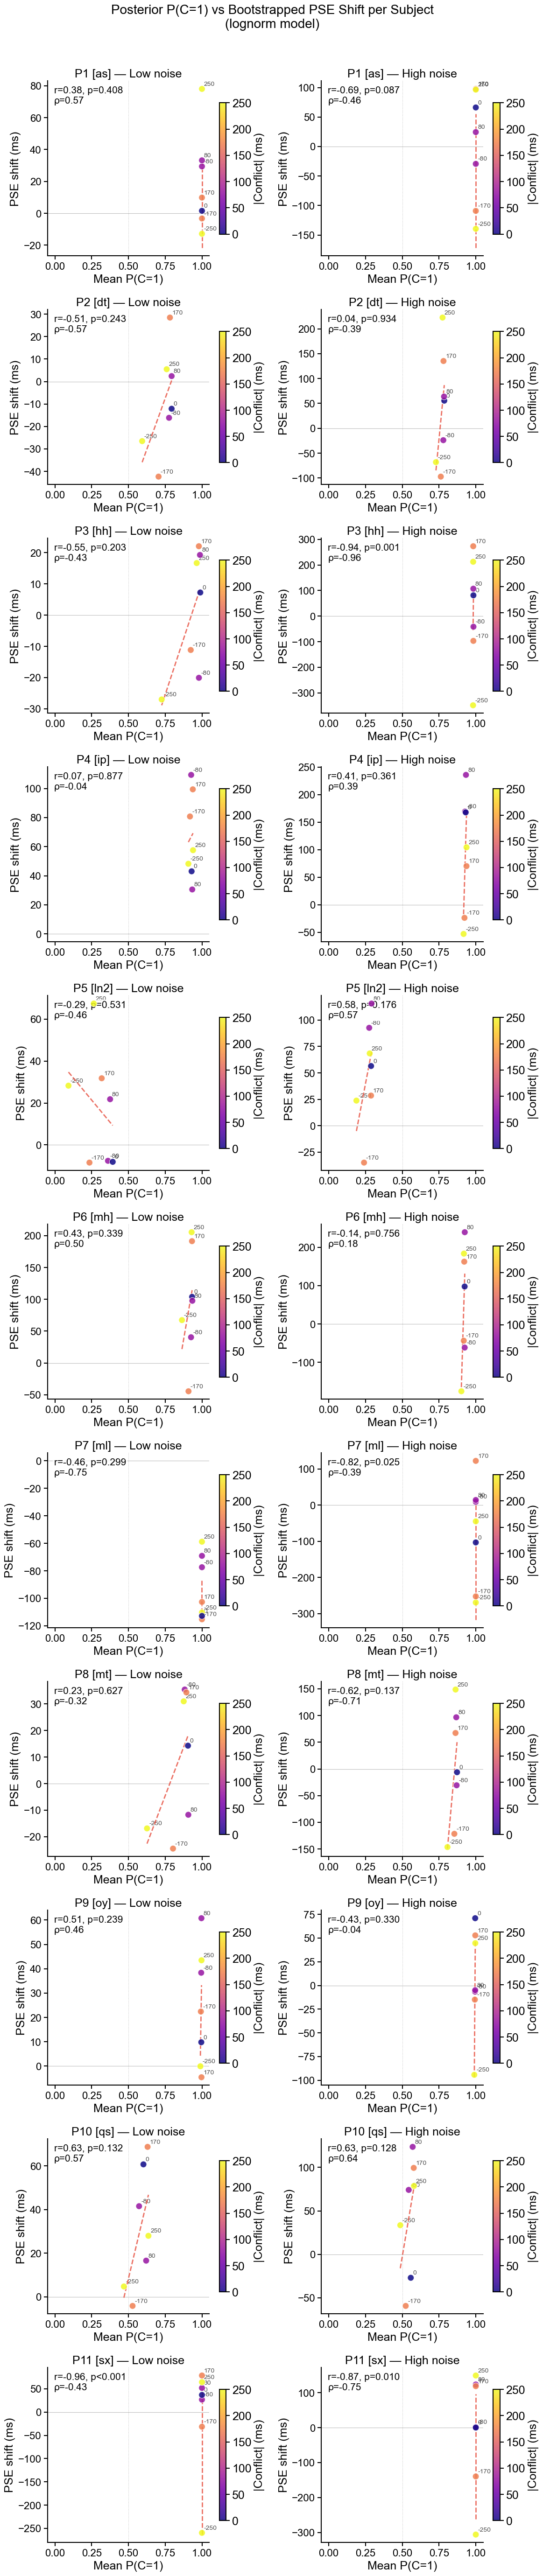

Saved: posterior_vs_pse_scatter.pdf


In [7]:
pids_plot = sorted(df_merged['participantID'].unique())
noise_levels = sorted(df_merged['audioNoise'].unique())
noise_labels = {noise_levels[0]: 'Low noise', noise_levels[1]: 'High noise'}

n_subj  = len(pids_plot)
n_noise = len(noise_levels)
FS = FONT_SIZE_LABEL

fig, axes = plt.subplots(n_subj, n_noise,
                          figsize=(6 * n_noise, 5 * n_subj),
                          squeeze=False)
plt.subplots_adjust(hspace=0.4, wspace=0.35)

abs_conflict_max = df_merged['conflict_ms'].abs().max()

for row_idx, pid in enumerate(pids_plot):
    for col_idx, noise_level in enumerate(noise_levels):
        ax = axes[row_idx, col_idx]

        sub = df_merged[
            (df_merged['participantID'] == pid) &
            (df_merged['audioNoise'] == noise_level)
        ].dropna(subset=['mean_posterior', 'mean_pse_ms'])

        if sub.empty:
            ax.set_visible(False)
            continue

        x   = sub['mean_posterior'].values
        y   = sub['mean_pse_ms'].values
        c_ms = sub['conflict_ms'].values

        # Color by |conflict| magnitude
        norm_c = plt.Normalize(vmin=0, vmax=abs_conflict_max)
        cmap   = plt.cm.plasma
        colors = cmap(norm_c(np.abs(c_ms)))

        sc = ax.scatter(x, y, c=np.abs(c_ms), cmap='plasma',
                        vmin=0, vmax=abs_conflict_max,
                        s=100, alpha=0.85, edgecolors='white', linewidths=0.8, zorder=5)

        # Annotate each point with conflict_ms label
        for xi, yi, ci in zip(x, y, c_ms):
            ax.annotate(f'{ci}', (xi, yi), fontsize=10, ha='left', va='bottom',
                        xytext=(3, 3), textcoords='offset points', alpha=0.7)

        # Linear regression line
        if len(x) >= 3:
            coefs   = np.polyfit(x, y, 1)
            x_line  = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, np.polyval(coefs, x_line),
                    color='#e74c3c', linewidth=2, linestyle='--', alpha=0.8, zorder=4)

        # Reference lines
        ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
        ax.axvline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5, label='P(C=1)=0.5')

        # Annotate with correlation stats
        corr_sub = df_corr[
            (df_corr['participantID'] == pid) &
            (df_corr['audioNoise'] == noise_level)
        ]
        if not corr_sub.empty:
            r  = corr_sub.iloc[0]['pearson_r_abs']
            p  = corr_sub.iloc[0]['pearson_p_abs']
            sr = corr_sub.iloc[0]['spearman_rho']
            p_str  = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
            annot  = f'r={r:.2f}, {p_str}\nρ={sr:.2f}'
            ax.text(0.04, 0.97, annot,
                    transform=ax.transAxes,
                    fontsize=FS - 3, va='top', ha='left',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=2))

        ax.set_xlabel('Mean P(C=1)', fontsize=FS)
        ax.set_ylabel('PSE shift (ms)', fontsize=FS)
        ax.set_xlim([-0.05, 1.05])
        ax.set_title(f'P{row_idx+1} [{pid}] — {noise_labels[noise_level]}',
                     fontsize=FS, pad=6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=FS - 2)

        plt.colorbar(sc, ax=ax, label='|Conflict| (ms)', shrink=0.75)

plt.suptitle('Posterior P(C=1) vs Bootstrapped PSE Shift per Subject\n(lognorm model)',
             fontsize=FONT_SIZE_TITLE, y=1.005)
plt.tight_layout()
plt.savefig('posterior_vs_pse_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: posterior_vs_pse_scatter.pdf")


## 8. Group-Level Summary: Mean Posterior vs Mean PSE Shift Across Subjects

Two panels (low noise / high noise) with dual y-axes:
- **Left axis (blue):** Group mean PSE shift (ms) ± SEM as a function of conflict
- **Right axis (green):** Group mean P(C=1) ± SEM as a function of conflict

If causal inference is driving PSE, the two curves should co-vary: as P(C=1) drops at large conflicts, the PSE slope should flatten.


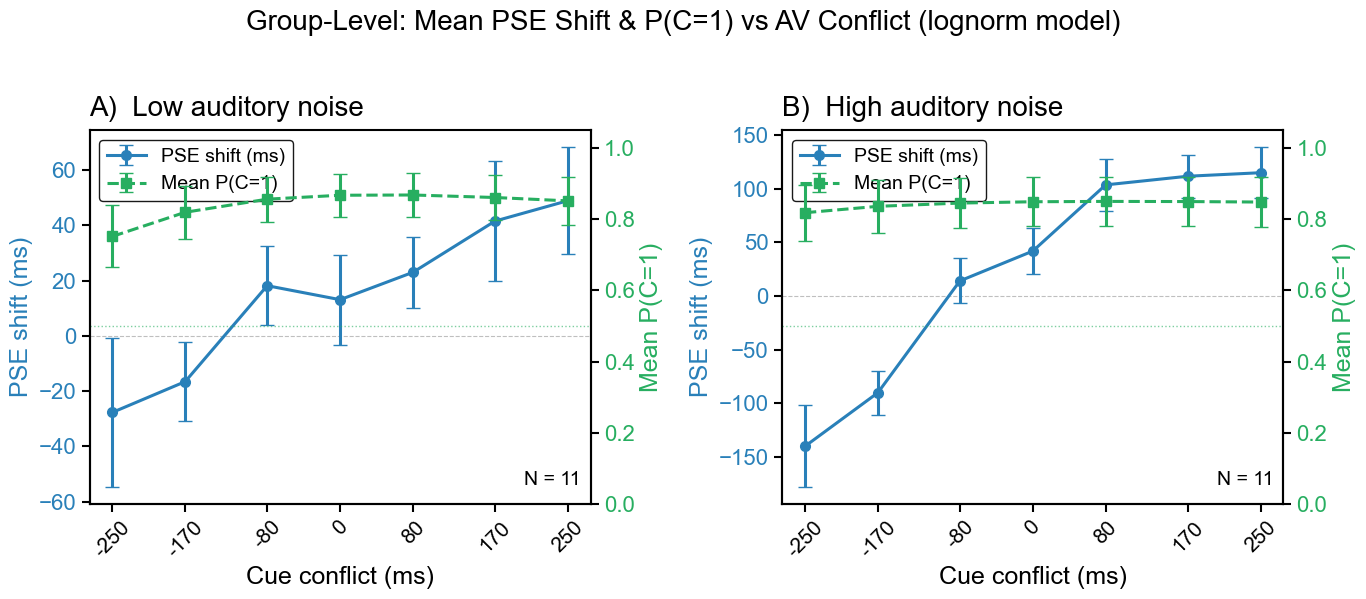

Saved: group_posterior_vs_pse.pdf


In [8]:
# ── Aggregate across participants ─────────────────────────────────────────────
group_agg = (
    df_merged
    .groupby(['audioNoise', 'conflict_ms'])
    .agg(
        mean_pse    = ('mean_pse_ms',   'mean'),
        sem_pse     = ('mean_pse_ms',   lambda x: x.std() / np.sqrt(len(x))),
        mean_post   = ('mean_posterior', 'mean'),
        sem_post    = ('mean_posterior', lambda x: x.std() / np.sqrt(len(x))),
        n           = ('participantID',  'count'),
    )
    .reset_index()
    .sort_values(['audioNoise', 'conflict_ms'])
)

panel_titles = ['A)  Low auditory noise', 'B)  High auditory noise']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

PSE_COLOR  = '#2980b9'   # blue
POST_COLOR = '#27ae60'   # green

for col_idx, noise_level in enumerate(sorted(group_agg['audioNoise'].unique())):
    sub  = group_agg[group_agg['audioNoise'] == noise_level].sort_values('conflict_ms')
    ax1  = axes[col_idx]
    ax2  = ax1.twinx()

    x = sub['conflict_ms'].values

    # ── PSE on left axis ──────────────────────────────────────────────────
    ax1.errorbar(x, sub['mean_pse'].values, yerr=sub['sem_pse'].values,
                 color=PSE_COLOR, fmt='o-', capsize=5, linewidth=2.2,
                 markersize=7, label='PSE shift (ms)', zorder=5)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax1.set_xlabel('Cue conflict (ms)', fontsize=FS)
    ax1.set_ylabel('PSE shift (ms)', color=PSE_COLOR, fontsize=FS)
    ax1.tick_params(axis='y', labelcolor=PSE_COLOR, labelsize=FS - 2)
    ax1.tick_params(axis='x', labelsize=FS - 2)
    ax1.set_xticks(x)
    ax1.set_xticklabels([str(int(xi)) for xi in x], rotation=45, fontsize=FS - 3)

    # ── Posterior on right axis ───────────────────────────────────────────
    ax2.errorbar(x, sub['mean_post'].values, yerr=sub['sem_post'].values,
                 color=POST_COLOR, fmt='s--', capsize=5, linewidth=2.2,
                 markersize=7, label='Mean P(C=1)', zorder=4)
    ax2.axhline(0.5, color=POST_COLOR, linestyle=':', linewidth=1, alpha=0.6)
    ax2.set_ylabel('Mean P(C=1)', color=POST_COLOR, fontsize=FS)
    ax2.tick_params(axis='y', labelcolor=POST_COLOR, labelsize=FS - 2)
    ax2.set_ylim([0, 1.05])

    ax1.set_title(panel_titles[col_idx], fontsize=FONT_SIZE_TITLE, loc='left', pad=10)
    ax1.spines['top'].set_visible(False)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc='upper left', fontsize=FS - 4, framealpha=0.9)

    # Number of subjects annotation
    ax1.text(0.98, 0.04, f'N = {sub["n"].iloc[0]}',
             transform=ax1.transAxes, fontsize=FS - 4,
             va='bottom', ha='right',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))

plt.suptitle('Group-Level: Mean PSE Shift & P(C=1) vs AV Conflict (lognorm model)',
             fontsize=FONT_SIZE_TITLE, y=1.01)
plt.tight_layout()
plt.savefig('group_posterior_vs_pse.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: group_posterior_vs_pse.pdf")


## 9. Flag Inconsistent Subjects: High P(C=1) Drop but Near-Linear PSE

**Inconsistency criterion:**  
A subject is flagged if at maximum |conflict|, their P(C=1) drops below a threshold (e.g. 0.5), yet the observed |PSE shift| at max conflict is still large relative to what causal inference would predict.

**Predicted PSE from causal inference model:**
$$\text{PSE}_{\text{pred}} \approx P(C=1) \times \text{(visual PSE shift)} + (1 - P(C=1)) \times 0$$

where visual PSE shift ≈ conflict (full capture), so:  
$$\text{PSE}_{\text{pred}} \approx P(C=1) \times \text{conflict\_ms}$$

**Discrepancy score** = |observed PSE| − |predicted PSE| per condition, averaged across conditions.


In [9]:
POST_THRESH = 0.5    # P(C=1) must drop below this to be considered "low posterior"
PSE_THRESH  = 20.0   # ms: PSE shift at max conflict must exceed this to be flagged

# ── Compute discrepancy scores ───────────────────────────────────────────────
discrepancy_rows = []

for pid in sorted(df_merged['participantID'].unique()):
    for noise_level in sorted(df_merged['audioNoise'].unique()):
        sub = df_merged[
            (df_merged['participantID'] == pid) &
            (df_merged['audioNoise'] == noise_level)
        ].dropna(subset=['mean_posterior', 'mean_pse_ms']).sort_values('conflict_ms')

        if sub.empty:
            continue

        # Simple CI prediction: PSE ≈ P(C=1) × conflict_ms (full visual capture baseline)
        sub = sub.copy()
        sub['predicted_pse'] = sub['mean_posterior'] * sub['conflict_ms']
        sub['discrepancy']   = np.abs(sub['mean_pse_ms']) - np.abs(sub['predicted_pse'])

        mean_discrepancy = sub['discrepancy'].mean()
        max_abs_conflict = sub['conflict_ms'].abs().max()

        # Min posterior at max |conflict| (both positive and negative conflict extremes)
        extremes = sub[sub['conflict_ms'].abs() == max_abs_conflict]
        min_posterior_at_extreme = extremes['mean_posterior'].min()
        pse_at_extreme           = extremes['mean_pse_ms'].abs().max()

        # Flag if posterior drops low at extremes AND PSE is still large
        flagged = (min_posterior_at_extreme < POST_THRESH) and (pse_at_extreme > PSE_THRESH)

        discrepancy_rows.append({
            'participantID':             pid,
            'audioNoise':                noise_level,
            'noise_label':               'Low noise' if noise_level == sorted(df_merged['audioNoise'].unique())[0] else 'High noise',
            'mean_discrepancy_ms':       round(mean_discrepancy, 2),
            'min_posterior_at_extreme':  round(min_posterior_at_extreme, 3),
            'pse_at_extreme_ms':         round(pse_at_extreme, 2),
            'flagged':                   flagged,
        })

df_disc = pd.DataFrame(discrepancy_rows).sort_values('mean_discrepancy_ms', ascending=False)

print(f"Inconsistency thresholds: P(C=1) < {POST_THRESH}, |PSE| > {PSE_THRESH} ms at max conflict\n")
print("── Discrepancy Table (ranked by mean discrepancy, high = more inconsistent) ──")
print(df_disc.to_string(index=False))

flagged_pids = df_disc[df_disc['flagged']]['participantID'].unique()
print(f"\nFlagged subjects: {sorted(flagged_pids)}")


Inconsistency thresholds: P(C=1) < 0.5, |PSE| > 20.0 ms at max conflict

── Discrepancy Table (ranked by mean discrepancy, high = more inconsistent) ──
participantID  audioNoise noise_label  mean_discrepancy_ms  min_posterior_at_extreme  pse_at_extreme_ms  flagged
           hh         1.2  High noise                25.34                     0.981             348.21    False
          ln2         1.2  High noise                24.12                     0.188              68.44     True
           mh         1.2  High noise                 6.64                     0.902             183.42    False
           qs         1.2  High noise                -6.77                     0.487              78.65     True
          ln2         0.1   Low noise                -9.80                     0.092              67.46     True
           dt         1.2  High noise               -13.87                     0.729             222.52    False
           ip         1.2  High noise               -14.8

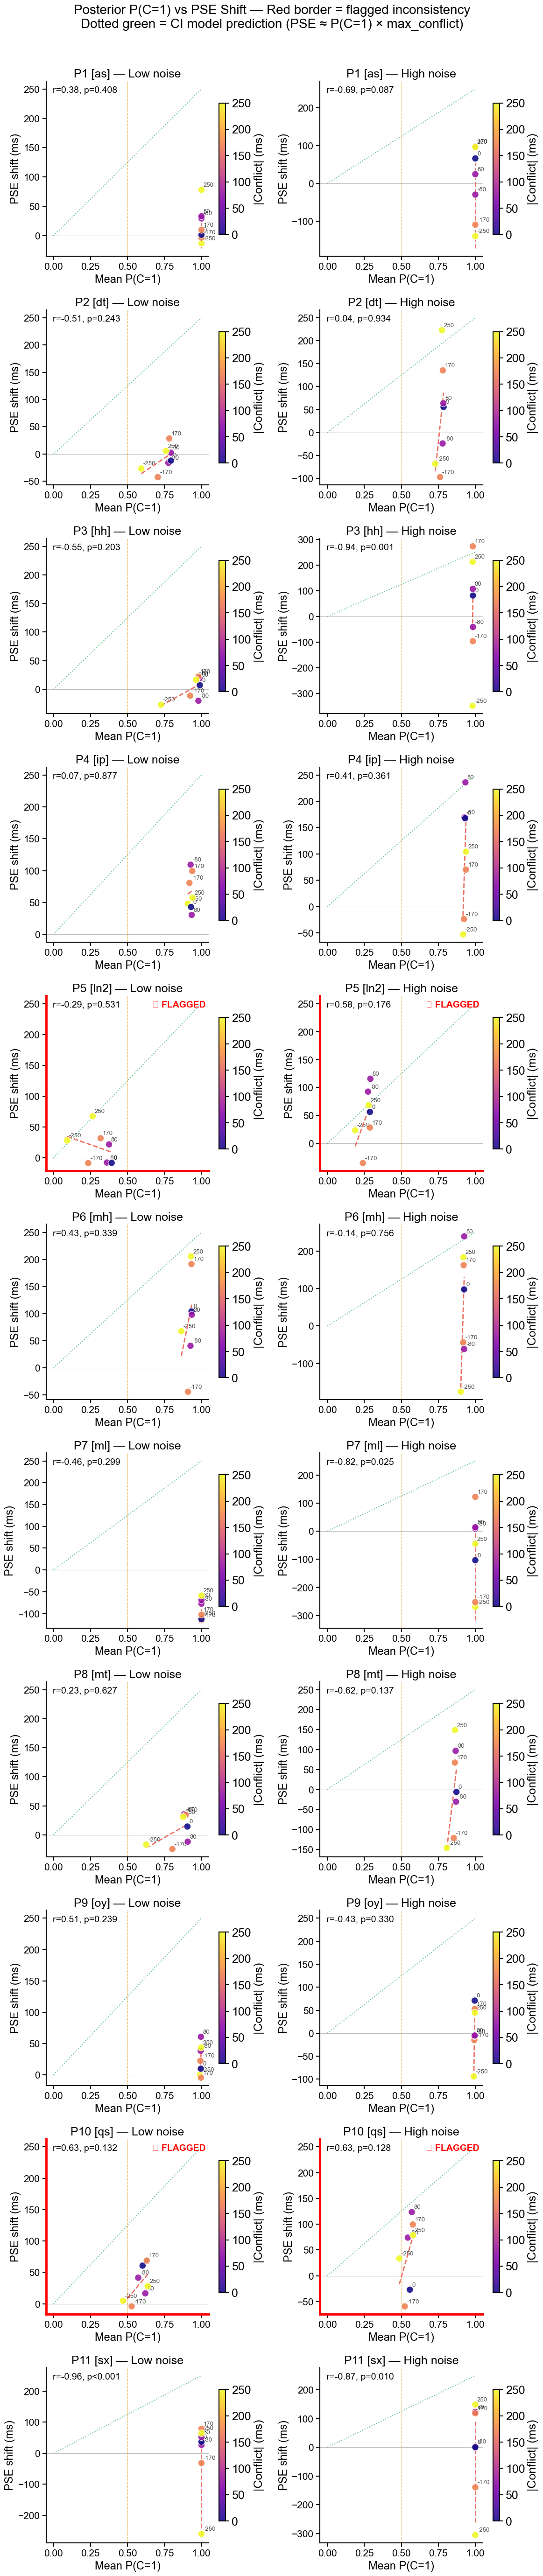

Saved: posterior_vs_pse_flagged.pdf

═══ INTERPRETATION GUIDE ═══
• Green dotted line: predicted PSE from full visual-capture CI model
  (PSE ≈ P(C=1) × conflict). Well-fitted subjects should cluster near this.
• Red-bordered panels: P(C=1) dropped below threshold but PSE stayed large
  → near-linear PSE despite low posterior = potential model/pipeline mismatch.
• Strong +r (top-right trend): posterior co-varies with PSE → CI mechanism plausible.
• Weak/flat r: PSE doesn't track posterior → may need different model or check pipeline.


In [10]:
# ── Re-draw subject scatter grid, highlighting flagged subjects ───────────────

fig, axes = plt.subplots(n_subj, n_noise,
                          figsize=(6 * n_noise, 5 * n_subj),
                          squeeze=False)
plt.subplots_adjust(hspace=0.45, wspace=0.38)

for row_idx, pid in enumerate(pids_plot):
    is_flagged_any_noise = pid in flagged_pids

    for col_idx, noise_level in enumerate(noise_levels):
        ax = axes[row_idx, col_idx]

        sub = df_merged[
            (df_merged['participantID'] == pid) &
            (df_merged['audioNoise'] == noise_level)
        ].dropna(subset=['mean_posterior', 'mean_pse_ms'])

        if sub.empty:
            ax.set_visible(False)
            continue

        x = sub['mean_posterior'].values
        y = sub['mean_pse_ms'].values
        c_ms = sub['conflict_ms'].values

        sc = ax.scatter(x, y, c=np.abs(c_ms), cmap='plasma',
                        vmin=0, vmax=abs_conflict_max,
                        s=110, alpha=0.88, edgecolors='white',
                        linewidths=0.8, zorder=5)

        for xi, yi, ci in zip(x, y, c_ms):
            ax.annotate(f'{ci}', (xi, yi), fontsize=9.5, ha='left', va='bottom',
                        xytext=(3, 3), textcoords='offset points', alpha=0.7)

        # Regression line
        if len(x) >= 3:
            coefs  = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, np.polyval(coefs, x_line),
                    color='#e74c3c', linewidth=2, linestyle='--', alpha=0.8, zorder=4)

        # Predicted PSE from CI model (dashed green)
        x_pred = np.linspace(0, 1, 50)
        # At the largest conflict level in this sub-block
        max_conf = sub['conflict_ms'].abs().max()
        ax.plot(x_pred, x_pred * max_conf, color='#27ae60',
                linewidth=1.5, linestyle=':', alpha=0.7, label=f'CI pred (max conflict={max_conf}ms)')

        ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
        ax.axvline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        ax.axvline(POST_THRESH, color='orange', linestyle='--', linewidth=1.0, alpha=0.6)

        # Correlation annotation
        corr_sub = df_corr[
            (df_corr['participantID'] == pid) &
            (df_corr['audioNoise'] == noise_level)
        ]
        if not corr_sub.empty:
            r  = corr_sub.iloc[0]['pearson_r_abs']
            p  = corr_sub.iloc[0]['pearson_p_abs']
            p_str  = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
            ax.text(0.04, 0.97, f'r={r:.2f}, {p_str}',
                    transform=ax.transAxes,
                    fontsize=FS - 4, va='top', ha='left',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=2))

        # Is this specific (pid, noise) flagged?
        disc_sub = df_disc[
            (df_disc['participantID'] == pid) &
            (df_disc['audioNoise'] == noise_level)
        ]
        is_flagged = not disc_sub.empty and disc_sub.iloc[0]['flagged']

        # Red border for flagged panels
        for spine in ax.spines.values():
            spine.set_linewidth(3.5 if is_flagged else 1.5)
            spine.set_edgecolor('red' if is_flagged else 'black')
        if is_flagged:
            ax.text(0.98, 0.97, '⚠ FLAGGED',
                    transform=ax.transAxes, fontsize=FS - 4,
                    va='top', ha='right', color='red', fontweight='bold')

        ax.set_xlabel('Mean P(C=1)', fontsize=FS - 1)
        ax.set_ylabel('PSE shift (ms)', fontsize=FS - 1)
        ax.set_xlim([-0.05, 1.05])
        ax.set_title(f'P{row_idx+1} [{pid}] — {noise_labels[noise_level]}',
                     fontsize=FS, pad=6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=FS - 3)

        plt.colorbar(sc, ax=ax, label='|Conflict| (ms)', shrink=0.75)

plt.suptitle('Posterior P(C=1) vs PSE Shift — Red border = flagged inconsistency\n'
             'Dotted green = CI model prediction (PSE ≈ P(C=1) × max_conflict)',
             fontsize=FONT_SIZE_TITLE, y=1.005)
plt.tight_layout()
plt.savefig('posterior_vs_pse_flagged.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: posterior_vs_pse_flagged.pdf")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n═══ INTERPRETATION GUIDE ═══")
print("• Green dotted line: predicted PSE from full visual-capture CI model")
print("  (PSE ≈ P(C=1) × conflict). Well-fitted subjects should cluster near this.")
print("• Red-bordered panels: P(C=1) dropped below threshold but PSE stayed large")
print("  → near-linear PSE despite low posterior = potential model/pipeline mismatch.")
print("• Strong +r (top-right trend): posterior co-varies with PSE → CI mechanism plausible.")
print("• Weak/flat r: PSE doesn't track posterior → may need different model or check pipeline.")
